In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd

In [3]:
df = gpd.read_file('Arkansas_precincts_topo.topojson')

In [4]:
df.head()

,id,GEOID,precinct,total_population,black_percentage,latino_percentage,other_percentage,geometry
0,0,05001-81 - Stuttgart 2,05001-81 - Stuttgart 2,2043,2.726383,0.298581,0.034263,"MULTIPOLYGON (((-91.52312 34.47879, -91.52342 ..."
1,1,05001-36 - Gillett Ward 3,05001-36 - Gillett Ward 3,94,1.063830,0.106383,0.212766,"POLYGON ((-91.38939 34.11621, -91.38765 34.116..."
2,2,05001-53 - Dewitt 2,05001-53 - Dewitt 2,554,1.859206,0.108303,0.090253,"POLYGON ((-91.32907 34.28235, -91.3327 34.2822..."
3,3,05001-51 - DeWitt 1,05001-51 - DeWitt 1,247,2.672065,0.000000,0.121457,"POLYGON ((-91.32907 34.28235, -91.32907 34.282..."
4,4,05001-55 - Dewitt 3,05001-55 - Dewitt 3,726,1.845730,0.096419,0.082645,"POLYGON ((-91.34061 34.30203, -91.34061 34.300..."


0.0     0.000000
0.1     0.000000
0.2     0.000000
0.3     0.043796
0.4     0.121581
0.5     0.286944
0.6     0.595533
0.7     1.440000
0.8     2.500000
0.9     4.374320
1.0    10.000000
Name: black_percentage, dtype: float64


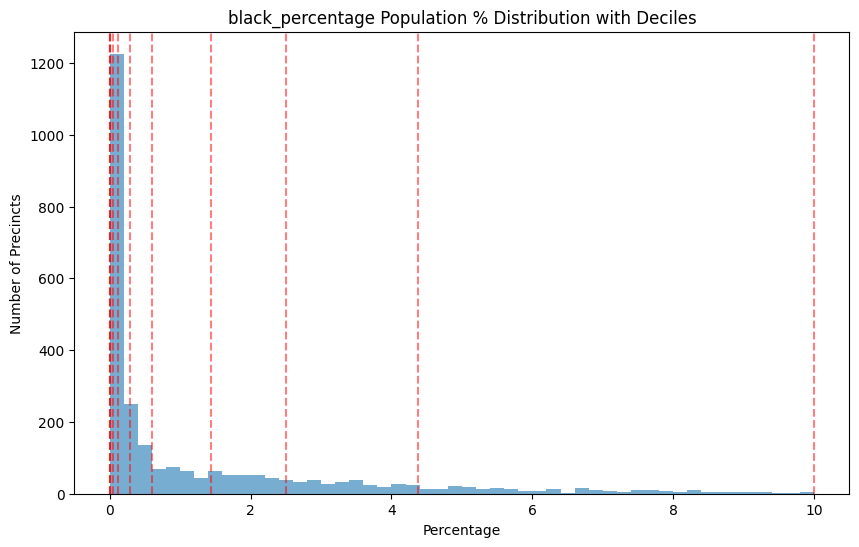

0.0    0.000000
0.1    0.000000
0.2    0.070423
0.3    0.136054
0.4    0.202922
0.5    0.273973
0.6    0.355097
0.7    0.471553
0.8    0.652174
0.9    0.971338
1.0    5.294118
Name: latino_percentage, dtype: float64


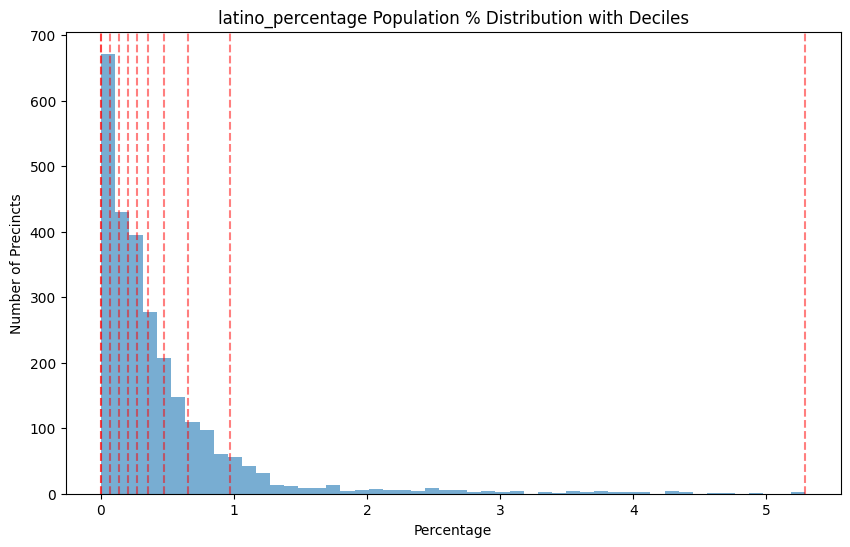

0.0    0.000000
0.1    0.055556
0.2    0.157017
0.3    0.215272
0.4    0.277778
0.5    0.332447
0.6    0.397580
0.7    0.483193
0.8    0.587338
0.9    0.793651
1.0    2.500000
Name: other_percentage, dtype: float64


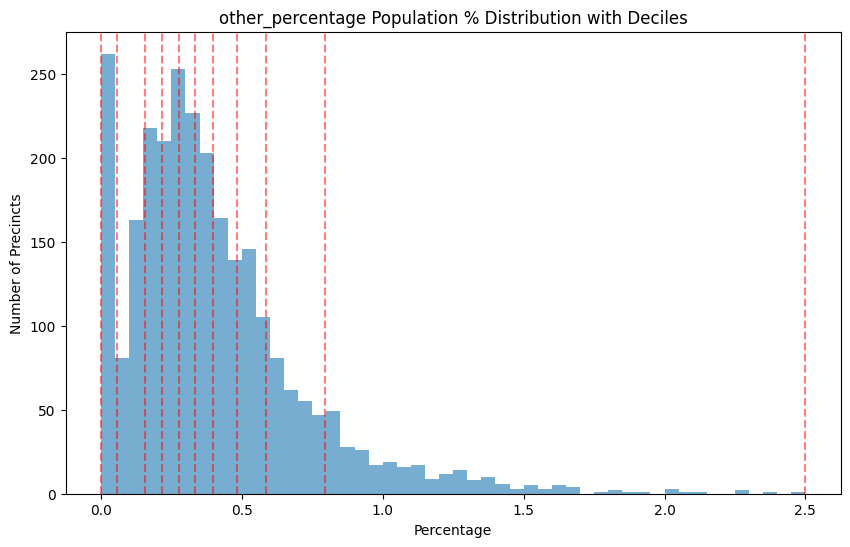

In [5]:
import matplotlib.pyplot as plt

races = ['black_percentage', 'latino_percentage', 'other_percentage']
for col in races:
    values = df[col]
    if values.isna().sum() > 0:
        print(f"{col} has nan")
    deciles = df[col].quantile(np.linspace(0, 1, 11))
    print(deciles)

    plt.figure(figsize=(10,6))

    plt.hist(values, bins=50, alpha=0.6)

    # draw vertical lines for deciles
    for d in deciles:
        plt.axvline(d, color="red", linestyle="--", alpha=0.5)

    plt.title(f"{col} Population % Distribution with Deciles")
    plt.xlabel("Percentage")
    plt.ylabel("Number of Precincts")
    plt.show()

In [11]:
import mapclassify
races = ['black', 'latino', 'other']
legend = {}
for race in races:
    values = np.log1p(df[f"{race}_percentage"])
    classifier = mapclassify.Quantiles(values, k=6)
    df[f"{race}_bin"] = classifier.yb
    legend[race] = {
        "bins": classifier.bins.tolist(),
        "min": float(values.min()),
        "max": float(values.max())
    }
    print(f"{race} bins: {classifier.bins}")
    
legend


black bins: [0.         0.06252036 0.25227045 0.74165377 1.39082682 2.39789527]
latino bins: [0.04115842 0.14429016 0.24214005 0.35717317 0.55142089 1.83961549]
other bins: [0.12479824 0.21115986 0.28701696 0.37343515 0.49141556 1.25276297]


{'black': {'bins': [0.0,
   0.06252035698133399,
   0.25227045129827225,
   0.7416537685099953,
   1.3908268181570673,
   2.3978952727983707],
  'min': 0.0,
  'max': 2.3978952727983707},
 'latino': {'bins': [0.04115842053376506,
   0.14429015980180623,
   0.2421400520048648,
   0.35717317001330195,
   0.5514208891794102,
   1.83961549040569],
  'min': 0.0,
  'max': 1.83961549040569},
 'other': {'bins': [0.12479824181691246,
   0.211159859424787,
   0.28701695769497027,
   0.37343514607179573,
   0.4914155566041797,
   1.252762968495368],
  'min': 0.0,
  'max': 1.252762968495368}}

In [12]:
import json
with open("Arkansas/Arkansas_legend.json", "w") as f:
    json.dump(legend, f)

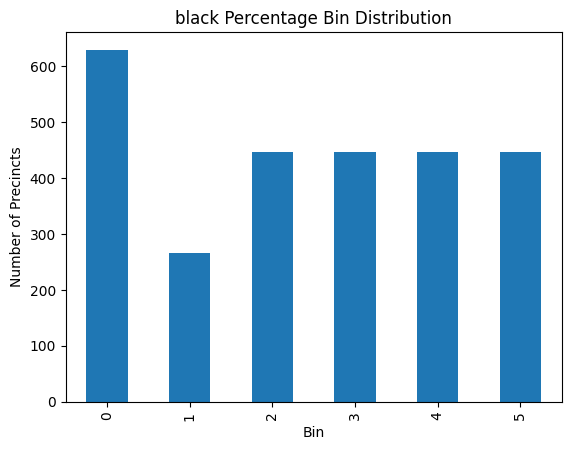

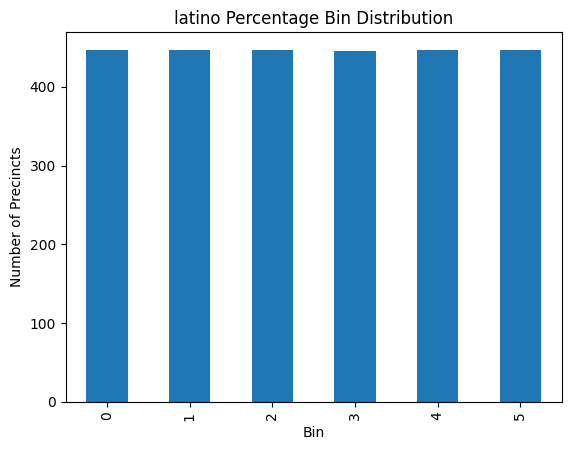

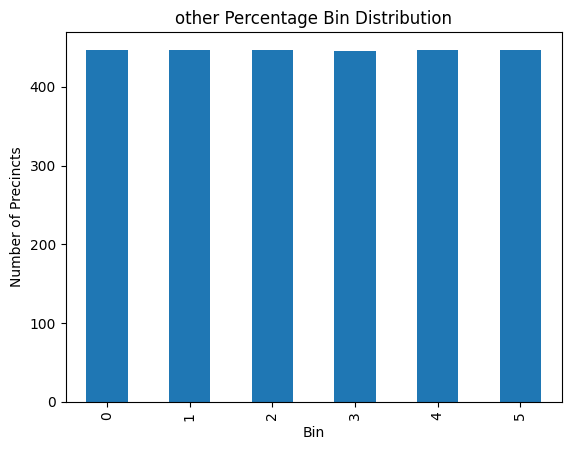

In [7]:
for race in races:
    df[f"{race}_bin"].value_counts().sort_index().plot(kind="bar")

    plt.title(f"{race} Percentage Bin Distribution")
    plt.xlabel("Bin")
    plt.ylabel("Number of Precincts")
    plt.show()

In [9]:
df['precinct'] = 'Precinct ' + df['precinct']
df.head()

,id,GEOID,precinct,total_population,black_percentage,latino_percentage,other_percentage,geometry,black_bin,latino_bin,other_bin
0,0,05001-81 - Stuttgart 2,Precinct 05001-81 - Stuttgart 2,2043,2.726383,0.298581,0.034263,"MULTIPOLYGON (((-91.52312 34.47879, -91.52342 ...",4,3,0
1,1,05001-36 - Gillett Ward 3,Precinct 05001-36 - Gillett Ward 3,94,1.063830,0.106383,0.212766,"POLYGON ((-91.38939 34.11621, -91.38765 34.116...",3,1,1
2,2,05001-53 - Dewitt 2,Precinct 05001-53 - Dewitt 2,554,1.859206,0.108303,0.090253,"POLYGON ((-91.32907 34.28235, -91.3327 34.2822...",4,1,0
3,3,05001-51 - DeWitt 1,Precinct 05001-51 - DeWitt 1,247,2.672065,0.000000,0.121457,"POLYGON ((-91.32907 34.28235, -91.32907 34.282...",4,0,0
4,4,05001-55 - Dewitt 3,Precinct 05001-55 - Dewitt 3,726,1.845730,0.096419,0.082645,"POLYGON ((-91.34061 34.30203, -91.34061 34.300...",4,1,0


In [10]:
import topojson as tp
topo = tp.Topology(df, prequantize=True)
topo.to_json("Arkansas_precincts_topo.topojson")